In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [3]:
df_data = pd.read_csv('data/raw/skill_builder_data.csv', encoding='ISO-8859-1', low_memory=False)
df_data.head()


,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,algebra,5948,13241,126,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,algebra,5948,13241,126,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,3,4,124564,30060,NaN,65,0,0.0,3,3.0


In [4]:
columns_to_keep = ['order_id', 'user_id', 'correct', 'skill_id', 'skill_name', 'problem_id',
                              'ms_first_response', 'bottom_hint', 'opportunity']
df_data_filtered = df_data[columns_to_keep]
df_data_filtered.isna().sum()


order_id                  0
user_id                   0
correct                   0
skill_id              66326
skill_name            78690
problem_id                0
ms_first_response         0
bottom_hint          445627
opportunity               0
dtype: int64

In [5]:
df_data_full = df_data_filtered.dropna(subset='skill_id')

df_data_full = df_data_full.copy()

df_data_full['bottom_hint'] = df_data_full['bottom_hint'].fillna(0)

df_data_full['opportunity_padded'] = df_data_full['opportunity'].apply(lambda x: f"{int(x):04d}")

# Create the 'timestamp' column by concatenating 'order_id' and padded 'opportunity'
df_data_full['timestamp'] = df_data_full['order_id'].astype(str) + df_data_full['opportunity_padded']

df_data_full.drop(columns=['opportunity', 'opportunity_padded', 'order_id'], inplace=True)

df_data_full.head()


,user_id,correct,skill_id,skill_name,problem_id,ms_first_response,bottom_hint,timestamp
0,64525,1,1.0,Box and Whisker,51424,32454,0.0,330225370001
1,64525,1,1.0,Box and Whisker,51435,4922,0.0,330227090002
2,70363,0,1.0,Box and Whisker,51444,25390,0.0,354502040001
3,70363,1,1.0,Box and Whisker,51395,4859,0.0,354502950002
4,70363,0,1.0,Box and Whisker,51481,19813,0.0,354503110003


In [5]:
df_data_full.dtypes

user_id                int64
correct                int64
skill_id             float64
skill_name            object
problem_id             int64
ms_first_response      int64
bottom_hint          float64
timestamp             object
dtype: object

In [6]:
df_data_full['skill_id'] = pd.to_numeric(df_data_full['skill_id'], errors='coerce').astype('Int64')
columns_to_int = ['correct', 'ms_first_response', 'bottom_hint']  # Replace with your column names
df_data_full[columns_to_int] = df_data_full[columns_to_int].astype(int)

# Convert specific columns to string
columns_to_str = ['user_id', 'skill_id', 'skill_name', 'problem_id', 'timestamp']  # Replace with your column names
df_data_full[columns_to_str] = df_data_full[columns_to_str].astype(str)

df_data_sorted = df_data_full.sort_values(by=['user_id', 'timestamp'])
df_data_sorted.head()


,user_id,correct,skill_id,skill_name,problem_id,ms_first_response,bottom_hint,timestamp
3957,14,0,2,Circle Graph,93383,26271,1,216176230001
94047,14,0,37,nan,93383,26271,1,216176230001
172411,14,0,70,Percent Of,93383,26271,1,216176230001
3958,14,1,2,Circle Graph,93407,29123,0,216176320002
94048,14,1,37,nan,93407,29123,0,216176320002


In [7]:
# Group by 'user_id' and 'timestamp' and count the unique 'problem_id' values for each group
unique_problem_ids_count = df_data_sorted.groupby(['user_id', 'timestamp'])['problem_id'].nunique().reset_index(name='unique_problem_id_count')

# Display the result
unique_problem_ids_count['unique_problem_id_count'].unique()


array([1], dtype=int64)

The check above means that correctly to one user-timestamp pair only one problem ID belongs.

IMPORTANT: however an answer can appear multiple times if it belongs to multiple skills. We wan this be consistent, so the same answer ID should be present for all its skill IDs every time. Because of this, we break our data into 2 parts: user-answer and answer-skill sets.

In [25]:
df_skill_problem_mapping = df_data_sorted[['skill_id', 'skill_name', 'problem_id']].drop_duplicates().sort_values(by='skill_id').reset_index(drop=True)
df_answers = df_data_sorted.drop(columns=['skill_id', 'skill_name']).drop_duplicates().reset_index(drop=True)
df_answers = df_answers.merge(df_skill_problem_mapping, on='problem_id')

cols = df_answers.columns.tolist()
cols[-1], cols[1] = cols[1], cols[-1]  # Swap second and last column positions
df_answers = df_answers[cols]  # Reorder the DataFrame with the new column order

# Step 2: Shuffle the DataFrame
df_answers = df_answers.sample(frac=1, random_state=42).reset_index(drop=True)

# Step 3: Order the DataFrame by 'user_id' and 'timestamp'
df_answers = df_answers.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)

# Display the modified DataFrame
df_answers.head(20)


,user_id,skill_name,problem_id,ms_first_response,bottom_hint,timestamp,skill_id,correct
0,14,Percent Of,93383,26271,1,216176230001,70,0
1,14,Circle Graph,93383,26271,1,216176230001,2,0
2,14,nan,93383,26271,1,216176230001,37,0
3,14,nan,93407,29123,0,216176320002,37,1
4,14,Circle Graph,93407,29123,0,216176320002,2,1
5,14,Percent Of,93407,29123,0,216176320002,70,1
6,14,nan,93400,13779,1,216176410003,37,0
7,14,Circle Graph,93400,13779,1,216176410003,2,0
8,14,Percent Of,93400,13779,1,216176410003,70,0
9,14,Percent Of,93419,16901,1,216176500004,70,0


We only want to keep user who answered at least and at most a certain amount of different problems and skills for which at least a certain amount of people gave answers, and one of them at least a certain amount of times.

In [ ]:
max_user_sequence_len = 400
min_user_sequence_len = 5

min_user_per_skill = 10
min_len_longest_seq = 3


## Valid users

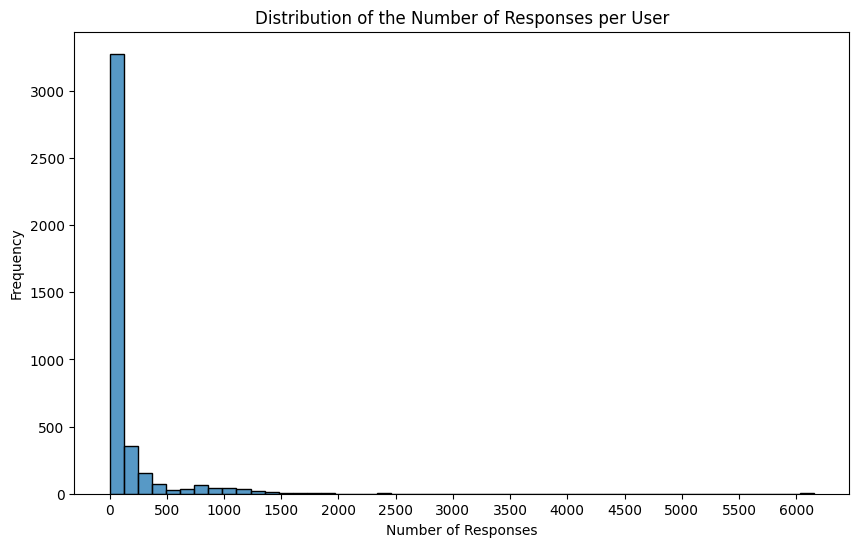

In [31]:
user_counts = df_answers['user_id'].value_counts()

plt.figure(figsize=(10, 6))
sns.histplot(user_counts, bins=50, kde=False)
plt.title('Distribution of the Number of Responses per User')
plt.xlabel('Number of Responses')
plt.ylabel('Frequency')
plt.xticks(range(0, max(user_counts), 500))  # Adjust range and step as needed

plt.show()


In [42]:
len_before = len(df_answers)

df_filtered_user = df_answers.groupby('user_id').filter(lambda x: len(x) >= min_user_sequence_len)

# Then, for each user_id, keep only the first max_user_sequence_len rows
df_answers_valid_user = df_filtered_user.groupby('user_id').head(max_user_sequence_len)

# Display the filtered DataFrame
len_after = len(df_answers_valid_user)
diff = len_before - len_after

print(f"{len_before} rows kept out for {len_after}, meaning that {diff} rows were dropped.")

546725 rows kept out for 350497, meaning that 196228 rows were dropped.


## Valid skills

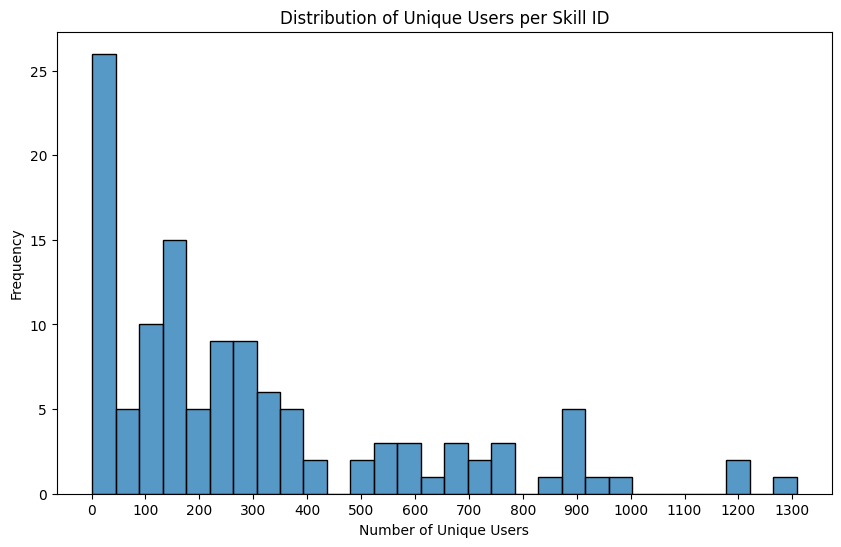

In [43]:
unique_users_per_skill = df_answers_valid_user.groupby('skill_id')['user_id'].nunique()

# Step 2: Plot a histogram of the number of unique users per skill_id
plt.figure(figsize=(10, 6))
sns.histplot(unique_users_per_skill, bins=30, kde=False)  # You can adjust bins as needed
plt.title('Distribution of Unique Users per Skill ID')
plt.xlabel('Number of Unique Users')
plt.ylabel('Frequency')
plt.xticks(range(0, max(unique_users_per_skill), 100))  # Adjust range and step as needed
plt.show()


Closer look

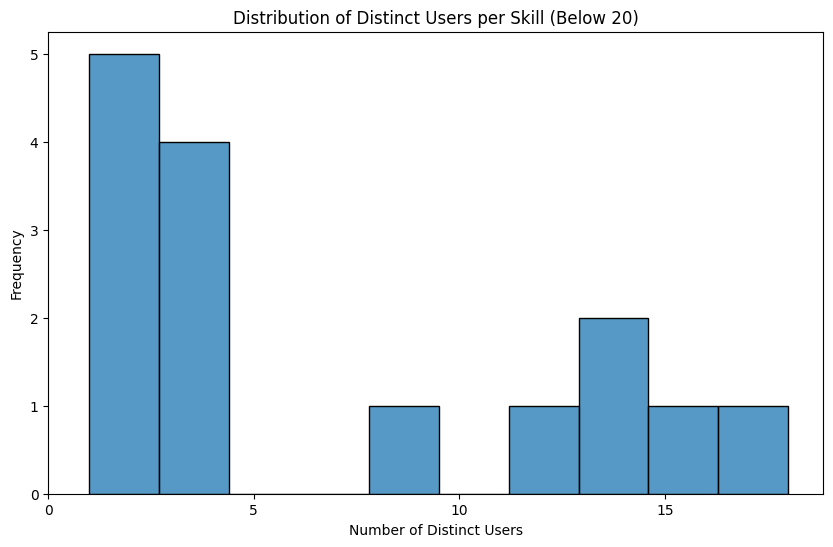

In [44]:
max_threshold = 20

unique_users_per_skill_min = unique_users_per_skill[unique_users_per_skill < max_threshold]
plt.figure(figsize=(10, 6))
sns.histplot(unique_users_per_skill_min, bins=10, kde=False)
plt.title('Distribution of Distinct Users per Skill (Below 20)')
plt.xlabel('Number of Distinct Users')
plt.ylabel('Frequency')
plt.xticks(range(0, max(unique_users_per_skill_min), 5))  # Adjust range and step as needed

plt.show()

In [45]:
len_before = len(df_answers_valid_user)

# Step 1: Identify skill_ids with less than 10 unique users
skills_to_remove = unique_users_per_skill[unique_users_per_skill < min_user_per_skill].index

# Step 2: Remove these skill_ids from the DataFrame
df_answers_valid_skills = df_answers_valid_user[~df_answers_valid_user['skill_id'].isin(skills_to_remove)]

# Confirm the change by checking the number of unique skill_ids left
# Display the filtered DataFrame
len_after = len(df_answers_valid_skills)
diff = len_before - len_after

print(f"{len_before} rows kept out for {len_after}, meaning that {diff} rows were dropped.")


350497 rows kept out for 350292, meaning that 205 rows were dropped.


For each skill we need at least one sequence, which has a length of at least a given value.

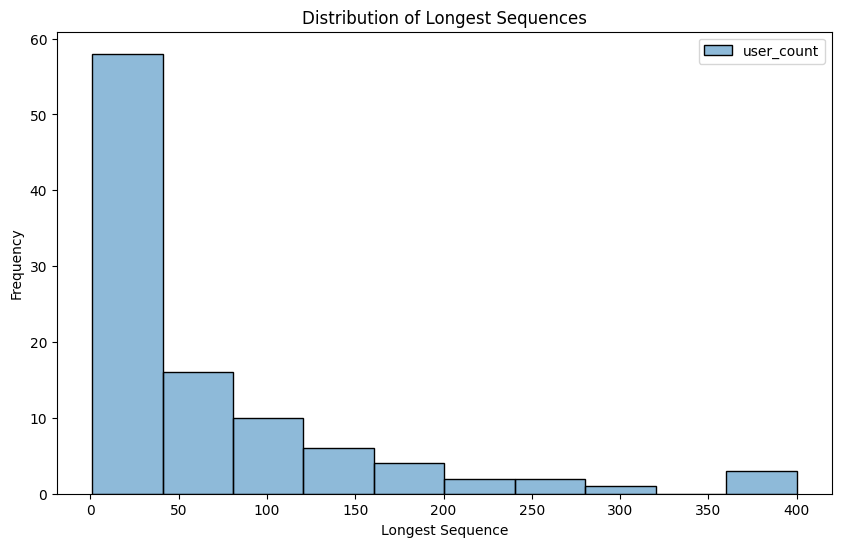

In [ ]:
# Step 1: Count how many times each user_id appears for each skill_id
user_skill_counts = df_answers_valid_skills.groupby(['skill_id', 'user_id']).size().reset_index(name='user_count')

# Step 2: Find the maximum user_count for each skill_id
df_max_user_count_per_skill = user_skill_counts.groupby('skill_id')['user_count'].max().reset_index()

plt.figure(figsize=(10, 6))
sns.histplot(df_max_user_count_per_skill, bins=10, kde=False)
plt.title('Distribution of Longest Sequences')
plt.xlabel('Longest Sequence')
plt.ylabel('Frequency')

plt.show()

In [ ]:


df_skill_ids_to_keep = df_max_user_count_per_skill[df_max_user_count_per_skill['user_count'] > min_len_longest_seq]
list_skills_to_keep = df_skill_ids_to_keep['skill_id'].unique()
df_skills = df_skills[df_skills['skill_id'].isin(list_skills_to_keep)]
df_problems_valid = df_problems_valid[df_problems_valid['problem_id'].isin(df_skills['problem_id'].unique())]


We have to check if a later filtering corrupted an earlier condition, hence we pack the filterings inside a function and do it until it does not have any effects.

In [38]:
def filter_valid(df_answers, df_skills):
    filtered_df = df_answers.groupby('user_id').filter(lambda x: len(x) >= min_user_sequence_len)

    # Then, for each user_id, keep only the first max_user_sequence_len rows
    filtered_df = filtered_df.groupby('user_id').head(max_user_sequence_len)
    filtered_df = filtered_df.groupby('problem_id').filter(lambda x: len(x) >= min_answers_per_problem)

    df_skills = df_skills[df_skills['problem_id'].isin(filtered_df['problem_id'])]
    
    df_skills_merged = pd.merge(filtered_df, df_skills, on='problem_id')
    df_skills_per_user = df_skills_merged.groupby('skill_id')['user_id'].nunique()
    list_skills_to_drop = df_skills_per_user[df_skills_per_user < min_user_per_skill].index

    df_skills = df_skills[~df_skills['skill_id'].isin(list_skills_to_drop)]
    filtered_df = filtered_df[filtered_df['problem_id'].isin(df_skills['problem_id'])]
    
    # Step 1: Count how many times each user_id appears for each skill_id
    df_skills_merged = pd.merge(filtered_df, df_skills, on='problem_id')
    user_skill_counts = df_skills_merged.groupby(['skill_id', 'user_id']).size().reset_index(name='user_count')
    df_max_user_count_per_skill = user_skill_counts.groupby('skill_id')['user_count'].max().reset_index()
    df_skill_ids_to_keep = df_max_user_count_per_skill[df_max_user_count_per_skill['user_count'] > min_len_longest_seq]
    list_skills_to_keep = df_skill_ids_to_keep['skill_id'].unique()
    df_skills = df_skills[df_skills['skill_id'].isin(list_skills_to_keep)]
    filtered_df = filtered_df[filtered_df['problem_id'].isin(df_skills['problem_id'].unique())]

    return filtered_df, df_skills

In [39]:
print(len(df_answers))
print(len(df_skills))
for i in range(5):
    print(i+1)
    df_answers, df_skills = filter_valid(df_answers, df_skills)
    print(len(df_answers))
    print(len(df_skills))

262347
10296
1
262347
10296
2
262347
10296
3
262347
10296
4
262347
10296
5
262347
10296


Hence, it is enough to do the steps 3 times.

## Final values

In [42]:
num_users = len(df_answers['user_id'].unique())
num_problems = len(df_skills['problem_id'].unique())
num_skills = len(df_skills['skill_id'].unique())
num_answers = len(df_answers)
print(f'Number of users: {num_users}')
print(f'Number of problems: {num_problems}')
print(f'Number of skills: {num_skills}')
print(f'Number of answers: {num_answers}')


Number of users: 3473
Number of problems: 8209
Number of skills: 85
Number of answers: 262347


## Original values

In [35]:
num_users_og = len(df_data['user_id'].unique())
num_problems_og = len(df_data['problem_id'].unique())
num_skills_og = len(df_data['skill_id'].unique())
num_answers_og = len(df_data)
print(f'Number of original users: {num_users_og}')
print(f'Number of original problems: {num_problems_og}')
print(f'Number of original skills: {num_skills_og}')
print(f'Number of original answers: {num_answers_og}')

Number of original users: 4217
Number of original problems: 26688
Number of original skills: 124
Number of original answers: 525534
